
# Lab 5: Scrodinger equation with FDM

 **Exercise** : Solve the radial Schrodinger for Hydrogen atom with FDM

 ### Hydrogen radial equation

The H atom has an electron of mass $m$ a $r$ distance to the pronton. The potential energy is given by

$U(r)= -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}$

The Schrodinger's equation for this system is

$$
-\dfrac{\hbar^2}{2m}\nabla^2 \psi(\vec{r}) + -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}\psi(\vec{r})= E\,\psi(\vec{r})$$

--- Primeros 3 Niveles de Energía Calculados vs Teóricos ---
n=1: E_FDM = -97520.56540 Hartree | E_Exacta = -0.50000 Hartree
n=2: E_FDM = -0.49945 Hartree | E_Exacta = -0.12500 Hartree
n=3: E_FDM = -0.12492 Hartree | E_Exacta = -0.05556 Hartree


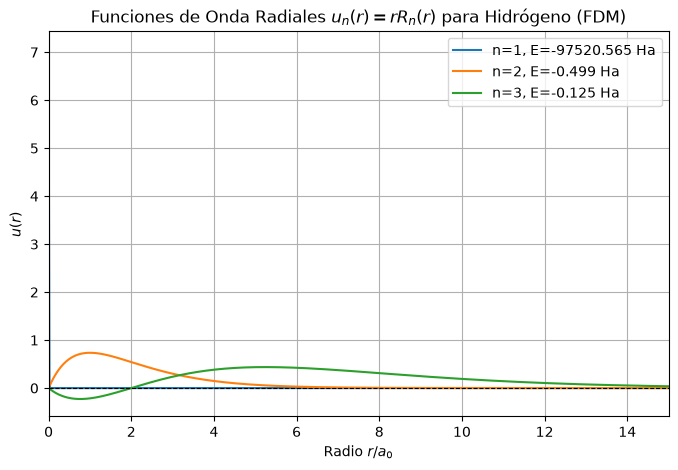

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

# ==========================================
# 1. PARÁMETROS Y MALLA ESPACIAL (Unidades Atómicas)
# ==========================================
r_min = 1e-5  # Evitar división por cero en r = 0
r_max = 20.0  # Radio máximo en unidades de a_0 (Bohr)
N = 1000      # Número de puntos de la malla

r = np.linspace(r_min, r_max, N)
dr = r[1] - r[0]

# ==========================================
# 2. POTENCIAL EFECTIVO Y MATRIZ FDM (l = 0)
# ==========================================
l = 0  # Momento angular orbital (Estado s)
V_eff = -1.0 / r + (l * (l + 1)) / (2.0 * r**2)

# Construcción de la matriz Hamiltoniana H = T + V
# Operador Segunda Derivada (-1/2 * d^2/dr^2)
diag_principal = (1.0 / dr**2) + V_eff
diag_secundaria = -0.5 / (dr**2) * np.ones(N - 1)

H = np.diag(diag_principal) + np.diag(diag_secundaria, k=1) + np.diag(diag_secundaria, k=-1)

# ==========================================
# 3. DIAGONALIZACIÓN (Autovalores y Autovectores)
# ==========================================
energies, wavefunctions = eigh(H)

# ==========================================
# 4. RESULTADOS Y VISUALIZACIÓN
# ==========================================
print("--- Primeros 3 Niveles de Energía Calculados vs Teóricos ---")
for n in range(1, 4):
    E_teorica = -0.5 / (n**2) # En Hartrees (-13.6 eV / n^2)
    print(f"n={n}: E_FDM = {energies[n-1]:.5f} Hartree | E_Exacta = {E_teorica:.5f} Hartree")

# Graficación de u(r) = r*R(r)
plt.figure(figsize=(8, 5))
for i in range(3):
    u_norm = wavefunctions[:, i] / np.sqrt(dr) # Normalización
    plt.plot(r, u_norm, label=f'n={i+1}, E={energies[i]:.3f} Ha')

plt.xlim(0, 15)
plt.title('Funciones de Onda Radiales $u_n(r) = r R_n(r)$ para Hidrógeno (FDM)')
plt.xlabel('Radio $r / a_0$')
plt.ylabel('$u(r)$')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.legend()
plt.grid(True)
plt.show()